##**Proyecto Integrador Final (Módulo 5): Valor de la Cuota del Fondo de Inversión**

Autora: Joanice Moreira Bastos

**Explicación del negocio:** Un fondo de inversión es un fondo común administrado por profesionales que invierten el dinero de los inversionistas en diferentes opciones como acciones, bonos o plazos fijos dependiendo del perfil.

Cada inversionista es dueño de una parte del fondo y esa parte se mide en cuotas calculada al cierre de cada día hábil.

**1. Carga de librerías y datos:**

In [ ]:
# 1.1. Librerías utilizadas:

# Para procesamiento de datos y números
import numpy as np
import pandas as pd
import os
import random
import tensorflow as tf

# Para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Para Series Temporales
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.gofplots import qqplot

# Para las métricas de los modelos
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Para Prophet
from prophet import Prophet

# Para LSTM
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, BatchNormalization, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Para Garch
!pip install arch
import arch

print("Librería 'arch' instalada e importada correctamente.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 7.4 MB/s eta 0:00:00
Librería 'arch' instalada e importada correctamente.


In [ ]:
# 1.2. Leyendo los archivos:

from google.colab import drive
drive.mount('/content/drive', force_remount = True)

url_csv = '/content/drive/MyDrive/Valor_Cuota.csv'
data_original = pd.read_csv(url_csv, encoding='latin1', sep=';')
data_original.head()

Mounted at /content/drive


,Fecha,Valor_Cuota_ATU,Valor_Cuota_CON,Valor_Cuota_MOD,Valor_Cuota_AGR
0,02/01/2015,"24,25183827","9,302920365","7,06113587","8,43452182"
1,05/01/2015,"24,23405626","9,318780332","7,035184784","8,374062672"
2,06/01/2015,"24,36516346","9,348411636","7,072217749","8,419591975"
3,07/01/2015,"24,46556703","9,350699862","7,124969638","8,516947096"
4,08/01/2015,"24,5163888","9,359604228","7,143776048","8,545802617"


**2. Análisis exploratorio de datos (EDA):**

In [ ]:
# 2.1. Verificando la información del dataset:

# creando una copia del dataset:
data = data_original.copy()

# Lista de columnas con el 'Valor_Cuota' para conversión de la coma por punto:
valor_columnas = ['Valor_Cuota_ATU', 'Valor_Cuota_CON', 'Valor_Cuota_MOD', 'Valor_Cuota_AGR']

# Iteración en las columnas y conversión del valor de la cuota:
for col in valor_columnas:
    if not pd.api.types.is_numeric_dtype(data[col]):
        data[col] = data[col].str.replace(',', '.', regex=False).astype(float)

# Ajustar opciones de visualización de pandas para mostrar todas las columnas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("Primeras 5 filas del DataFrame con la conversión de coma a punto:")
print(data.head())

print(data.info())

Primeras 5 filas del DataFrame con la conversión de coma a punto:
        Fecha  Valor_Cuota_ATU  Valor_Cuota_CON  Valor_Cuota_MOD  Valor_Cuota_AGR
0  02/01/2015        24.251838         9.302920         7.061136         8.434522
1  05/01/2015        24.234056         9.318780         7.035185         8.374063
2  06/01/2015        24.365163         9.348412         7.072218         8.419592
3  07/01/2015        24.465567         9.350700         7.124970         8.516947
4  08/01/2015        24.516389         9.359604         7.143776         8.545803
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2760 entries, 0 to 2759
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Fecha            2760 non-null   object 
 1   Valor_Cuota_ATU  2760 non-null   float64
 2   Valor_Cuota_CON  2760 non-null   float64
 3   Valor_Cuota_MOD  2760 non-null   float64
 4   Valor_Cuota_AGR  2760 non-null   float64
dtypes: float6

In [ ]:
# 2.2. Verificación de valores únicos:

unique_values = data.nunique()
{"Valores únicos": unique_values}

{'Valores únicos': Fecha              2760
 Valor_Cuota_ATU    2760
 Valor_Cuota_CON    2759
 Valor_Cuota_MOD    2760
 Valor_Cuota_AGR    2760
 dtype: int64}

In [ ]:
# 2.3. Encontrar los valores duplicados en la columna 'Valor_Cuota_CON'

duplicated_valor_cuota_con_rows = data[data['Valor_Cuota_CON'].duplicated(keep=False)]

print("Fila(s) con valores duplicados en 'Valor_Cuota_CON':")
display(duplicated_valor_cuota_con_rows)

Fila(s) con valores duplicados en 'Valor_Cuota_CON':


,Fecha,Valor_Cuota_ATU,Valor_Cuota_CON,Valor_Cuota_MOD,Valor_Cuota_AGR
106,09/06/2015,25.912125,9.89411,7.524663,8.983218
107,10/06/2015,25.962019,9.89411,7.552718,9.038948


**Interpretación de la duplicidad:** El Valor_Cuota_CON de los días 09 y 10 de junio fue el mismo en la cartera conservadora, hecho que consideramos no representativo dado que ocurrió solo una vez en las 2760 filas y en solo una de las cuatro carteras.

In [ ]:
# 2.4. Verificación de valores nulos:

missing_values = data.isnull().sum()
{"Valores nulos": missing_values }

{'Valores nulos': Fecha              0
 Valor_Cuota_ATU    0
 Valor_Cuota_CON    0
 Valor_Cuota_MOD    0
 Valor_Cuota_AGR    0
 dtype: int64}

In [ ]:
# 2.5. Verificación de valores ausentes:

missing_values = data.isnull().sum()

print("Valores ausentes por columna en data:")
print(missing_values)

Valores ausentes por columna en data:
Fecha              0
Valor_Cuota_ATU    0
Valor_Cuota_CON    0
Valor_Cuota_MOD    0
Valor_Cuota_AGR    0
dtype: int64


In [ ]:
# 2.6. Estadísticas descriptivas:

data.describe()

,Valor_Cuota_ATU,Valor_Cuota_CON,Valor_Cuota_MOD,Valor_Cuota_AGR
count,2760.000000,2760.000000,2760.000000,2760.000000
mean,45.204735,16.484189,13.130020,15.503983
std,12.313789,4.186833,3.591862,4.313542
min,24.234056,9.302920,7.035185,8.146044
25%,35.785322,13.381061,10.317065,11.955151
50%,46.455096,16.674708,13.649363,16.352306
75%,53.289564,19.527822,15.446365,18.220580
max,70.974637,25.405400,20.519015,24.242590


**Interpretación del análisis descriptivo:** La cartera actuarial, que es la cartera principal, tiene el mayor valor medio de la cuota (45.20) y la desviación estándar más volátil (12.31) en comparación con las otras carteras. Esta cartera concentra el 56% de los activos totales del fondo de inversión.

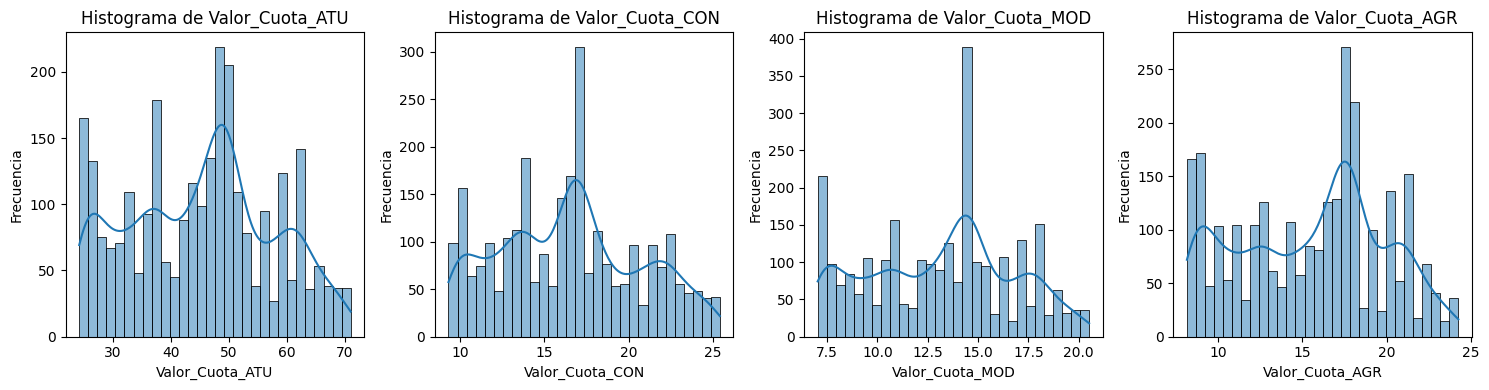

In [ ]:
# 2.7. HISTOGRAMA de todas las variables numéricas con KDE:

# Obtener solo las columnas numéricas
numerical_cols = data._get_numeric_data().columns.tolist()

# Calcular el número de subplots necesarios
num_cols = 4  # Número de columnas por fila en la visualización
num_rows = (len(numerical_cols) + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 4 * num_rows))
axes = axes.flatten() # Aplanar la matriz de axes para fácil iteración

# Generar un histplot con KDE para cada variable numérica
for i, col in enumerate(numerical_cols):
    sns.histplot(data[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Histograma de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

# Eliminar cualquier subplot no utilizado si el número de variables no es un múltiplo de num_cols
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

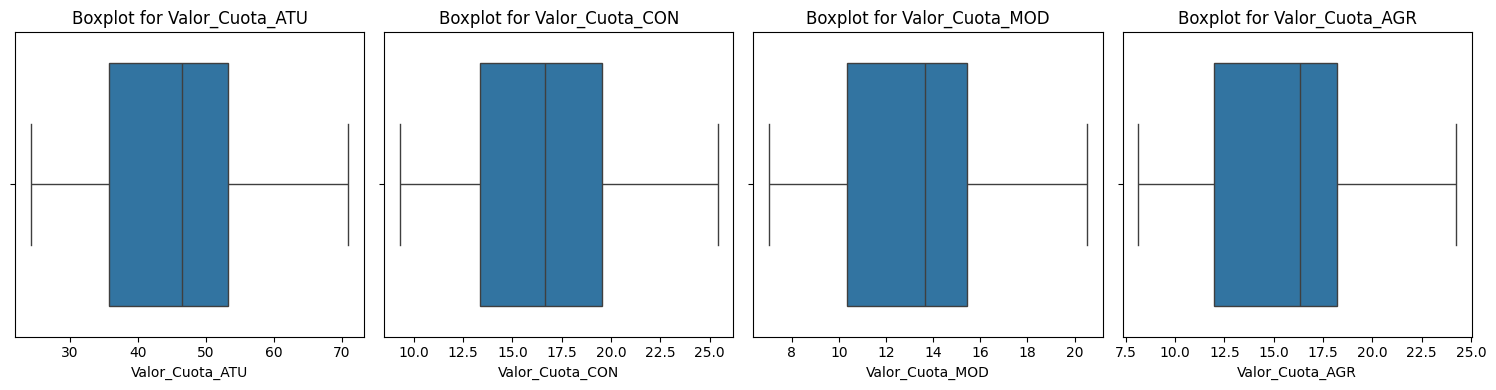

In [ ]:
# 2.8. Visualización de Boxplot para todas las variables numéricas:

# Identificar las columnas numéricas para los boxplots
caracteristicas_numericas = data.select_dtypes(include=np.number).columns.tolist()

# Definición del número de columnas deseado
num_columnas = 4
# Calcular el número de líneas necesario para todos los gráficos
num_lineas = (len(caracteristicas_numericas) + num_columnas - 1) // num_columnas

fig, axes = plt.subplots(num_lineas, num_columnas, figsize=(15, 4 * num_lineas))
axes = axes.ravel()

# Boxplots para cada una de las variables numéricas:
for i, feature in enumerate(caracteristicas_numericas):
    if i < len(axes):
        ax = axes[i]
        sns.boxplot(data=data, x=feature, ax=ax)
        ax.set_title(f'Boxplot for {feature}')
        ax.set_xlabel(feature)

# Remove any unused subplots
for j in range(len(caracteristicas_numericas), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # espacio entre los gráficos
plt.show()

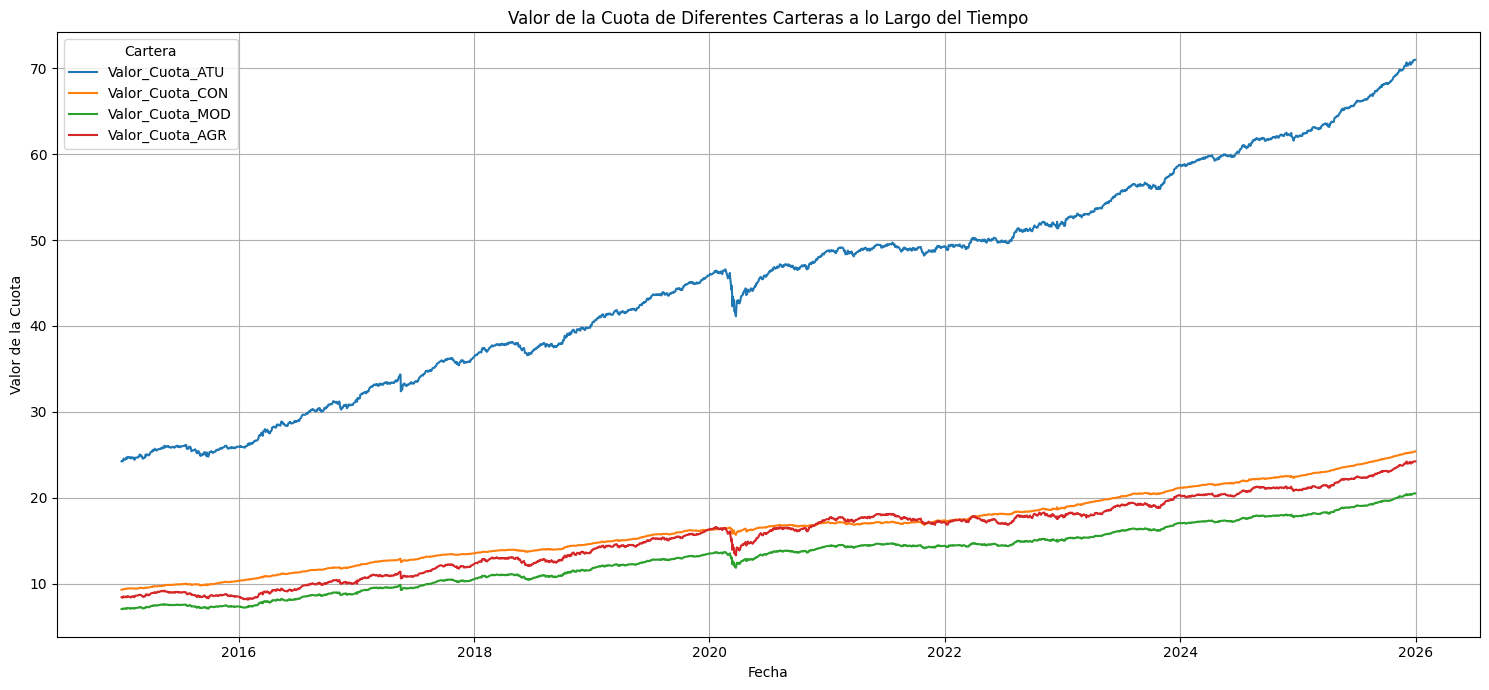

In [ ]:
# 2.9. Visualización del valor cuota de las carteras:

# Asegurarse de que 'Fecha' sea tipo datetime
data['Fecha'] = pd.to_datetime(data['Fecha'], format='%d/%m/%Y', errors='coerce')

# Establecer 'Fecha' como índice si se prefiere para series de tiempo, o simplemente usarla para el eje x
# En este caso, la usaré directamente como eje x para permitir múltiples líneas fácilmente.

plt.figure(figsize=(15, 7))

# Columnas con los valores de cuota a graficar
valor_cuota_cols = ['Valor_Cuota_ATU', 'Valor_Cuota_CON', 'Valor_Cuota_MOD', 'Valor_Cuota_AGR']

for col in valor_cuota_cols:
    sns.lineplot(x='Fecha', y=col, data=data, label=col)

plt.title('Valor de la Cuota de Diferentes Carteras a lo Largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Valor de la Cuota')
plt.legend(title='Cartera')
plt.grid(True)
plt.tight_layout()
plt.show()

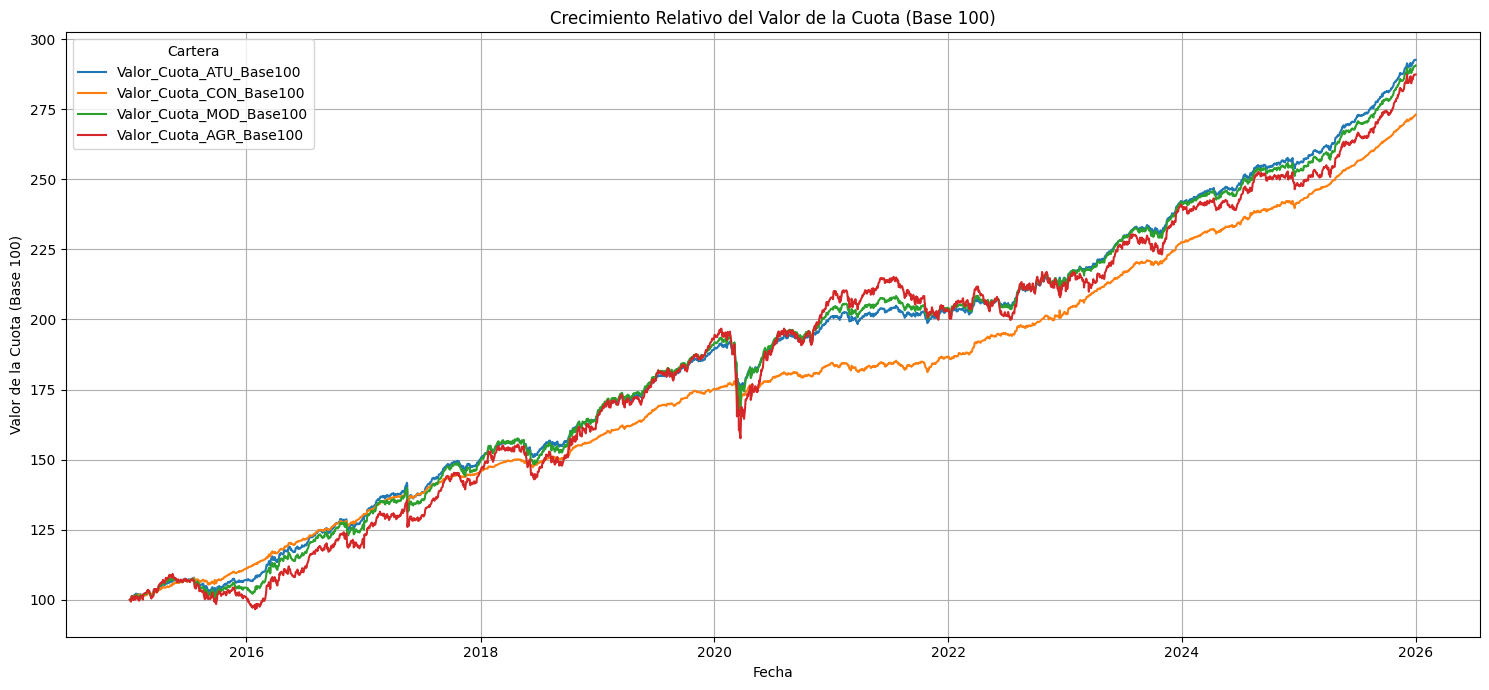

In [ ]:
# 2.10. Gráfico de Líneas (Base 100):

# Crear una copia del DataFrame para no modificar el original
data_normalized = data.copy()

# Columnas con los valores de cuota
valor_cuota_cols = ['Valor_Cuota_ATU', 'Valor_Cuota_CON', 'Valor_Cuota_MOD', 'Valor_Cuota_AGR']

# Normalizar cada columna a base 100 en el primer día
for col in valor_cuota_cols:
    first_value = data_normalized[col].iloc[0]
    data_normalized[col + '_Base100'] = (data_normalized[col] / first_value) * 100

# Preparar los datos para graficar en formato largo para seaborn
data_long = data_normalized.melt(id_vars=['Fecha'], value_vars=[col + '_Base100' for col in valor_cuota_cols],
                                 var_name='Cartera', value_name='Valor_Base100')

plt.figure(figsize=(15, 7))
sns.lineplot(x='Fecha', y='Valor_Base100', hue='Cartera', data=data_long)

plt.title('Crecimiento Relativo del Valor de la Cuota (Base 100)')
plt.xlabel('Fecha')
plt.ylabel('Valor de la Cuota (Base 100)')
plt.legend(title='Cartera')
plt.grid(True)
plt.tight_layout()
plt.show()

**Gráfico Base 100:** Al normalizar todas las carteras a un valor de 100 en la fecha inicial, eliminamos el impacto de sus diferentes valores absolutos de partida. Esto nos permite compararlas en igualdad de condiciones.

###**Objetivo:** Realizar la predicción diaria del valor cuota de la cartera Atuarial para el año 2025.

In [ ]:
# 2.10. Filtrado de las columnas 'Fecha' y 'Valor_Cuota_ATU':

# Conversión del formato de la columna 'Fecha'
data['Fecha'] = pd.to_datetime(data['Fecha'], format='%d/%m/%Y')

# Filtrar para considerar solo días hábiles (lunes=0 a viernes=4)
data = data[data['Fecha'].dt.dayofweek < 5]

#data = data.set_index('Fecha')

# Asegurarse de que 'Fecha' sea el índice del DataFrame y tenga una frecuencia definida
# Esto es esencial para seasonal_decompose
data_indexed = data[['Fecha', 'Valor_Cuota_ATU']].copy()

display(data_indexed.head())
print(data_indexed.info())

,Fecha,Valor_Cuota_ATU
0,2015-01-02,24.251838
1,2015-01-05,24.234056
2,2015-01-06,24.365163
3,2015-01-07,24.465567
4,2015-01-08,24.516389


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2760 entries, 0 to 2759
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Fecha            2760 non-null   datetime64[ns]
 1   Valor_Cuota_ATU  2760 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 43.3 KB
None


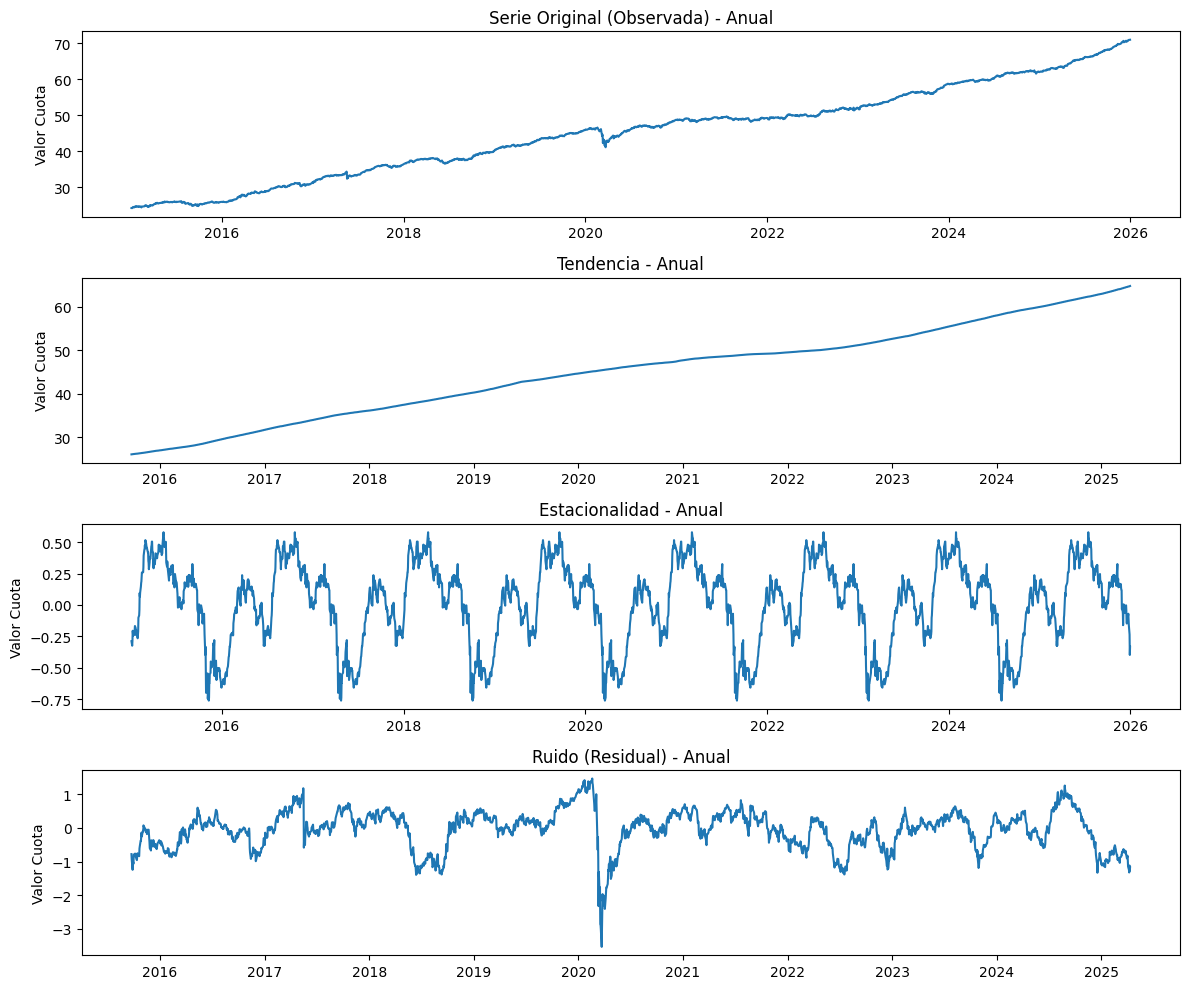

In [ ]:
# 2.11. Análisis de la Serie Original, Tendencia, Estacionalidad y Ruido (con Estacionalidad Anual):

# Asegurarse de que 'Fecha' sea el índice del DataFrame
# Esto es esencial para seasonal_decompose. Creamos una copia para no modificar el data_indexed original si se usa en otro lugar.
data_for_decomposition = data_indexed.set_index('Fecha')

# Usar los datos diarios de Valor_Cuota_ATU para la descomposición
daily_data = data_for_decomposition['Valor_Cuota_ATU']

# Realizar la descomposición de la serie temporal en los datos diarios
# Usamos un modelo aditivo y un período de 365 para capturar la estacionalidad anual.
decomposition = seasonal_decompose(daily_data, model='additive', period=365)

# Plotear la descomposición
plt.figure(figsize=(12, 10))

plt.subplot(411)
plt.plot(decomposition.observed)
plt.title('Serie Original (Observada) - Anual')
plt.ylabel('Valor Cuota')

plt.subplot(412)
plt.plot(decomposition.trend)
plt.title('Tendencia - Anual')
plt.ylabel('Valor Cuota')

plt.subplot(413)
plt.plot(decomposition.seasonal)
plt.title('Estacionalidad - Anual')
plt.ylabel('Valor Cuota')

plt.subplot(414)
plt.plot(decomposition.resid)
plt.title('Ruido (Residual) - Anual')
plt.ylabel('Valor Cuota')

plt.tight_layout()
plt.show()


In [ ]:
print("Rango de fechas de los componentes descompuestos (solo valores no nulos):")
print(f"- Observado: {decomposition.observed.first_valid_index()} a {decomposition.observed.last_valid_index()}")
print(f"- Tendencia: {decomposition.trend.first_valid_index()} a {decomposition.trend.last_valid_index()}")
print(f"- Estacionalidad: {decomposition.seasonal.first_valid_index()} a {decomposition.seasonal.last_valid_index()}")
print(f"- Ruido: {decomposition.resid.first_valid_index()} a {decomposition.resid.last_valid_index()}")

Rango de fechas de los componentes descompuestos (solo valores no nulos):
- Observado: 2015-01-02 00:00:00 a 2025-12-31 00:00:00
- Tendencia: 2015-09-24 00:00:00 a 2025-04-11 00:00:00
- Estacionalidad: 2015-01-02 00:00:00 a 2025-12-31 00:00:00
- Ruido: 2015-09-24 00:00:00 a 2025-04-11 00:00:00


Día hábil con mayor estacionalidad: Viernes (Valor promedio: 0.0202)
Día hábil con menor estacionalidad: Miércoles (Valor promedio: 0.0049)


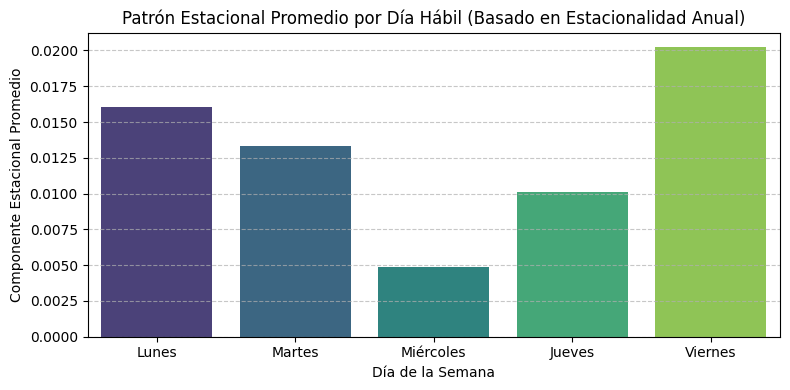

In [ ]:
# 2.12. Identificación del día hábil con mayor y menor estacionalidad

# Obtener el componente estacional de la descomposición
seasonal_component = decomposition.seasonal

# Crear un DataFrame temporal con el componente estacional y el día de la semana
# El índice del componente estacional ya es de tipo datetime
seasonal_df = pd.DataFrame({
    'Seasonal_Component': seasonal_component,
    'Day_of_Week': seasonal_component.index.dayofweek
})

# Mapear los números de día a nombres de día para una mejor lectura
day_names = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
seasonal_df['Day_Name'] = seasonal_df['Day_of_Week'].map(lambda x: day_names[x])

# Filtrar para considerar solo días hábiles (lunes=0 a viernes=4)
working_days_seasonal = seasonal_df[seasonal_df['Day_of_Week'] < 5]

# Calcular el promedio del componente estacional para cada día hábil
average_seasonal_pattern = working_days_seasonal.groupby('Day_Name')['Seasonal_Component'].mean()

# Definir el orden deseado de los días de la semana
desired_day_order = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes']

# Reordenar la serie según el orden deseado
average_seasonal_pattern = average_seasonal_pattern.reindex(desired_day_order)

# Identificar el día con mayor y menor estacionalidad (después de reordenar para el print)
day_with_highest_seasonality = average_seasonal_pattern.idxmax()
value_highest = average_seasonal_pattern.max()
day_with_lowest_seasonality = average_seasonal_pattern.idxmin()
value_lowest = average_seasonal_pattern.min()

print(f"Día hábil con mayor estacionalidad: {day_with_highest_seasonality} (Valor promedio: {value_highest:.4f})")
print(f"Día hábil con menor estacionalidad: {day_with_lowest_seasonality} (Valor promedio: {value_lowest:.4f})")

# Opcional: Visualizar el patrón estacional promedio por día hábil
plt.figure(figsize=(8, 4))
sns.barplot(x=average_seasonal_pattern.index, y=average_seasonal_pattern.values, hue=average_seasonal_pattern.index, palette='viridis', legend=False)
plt.title('Patrón Estacional Promedio por Día Hábil (Basado en Estacionalidad Anual)')
plt.xlabel('Día de la Semana')
plt.ylabel('Componente Estacional Promedio')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Interpretación de la descomposición**:

1.	**Serie Original**: Clara tendencia ascendente en el valor de la cuota a lo largo del tiempo, con algunas fluctuaciones.
2.	**Tendencia**: Confirma un crecimiento sostenido en el valor de la cuota durante el período analizado.
3.	**Estacionalidad**: Muestra un patrón recurrente anual, indicando que el valor de la cuota tiene comportamientos similares en las mismas épocas de cada año (por ejemplo, subidas o bajadas en ciertos meses).
4.	**Ruido (Residual)**: Representa las variaciones aleatorias o irregulares que no se explican por la tendencia ni por la estacionalidad anual.


Prueba de Dickey-Fuller (p-valor): 0.9956
Resultado: La serie NO es estacionaria (requiere diferenciación).


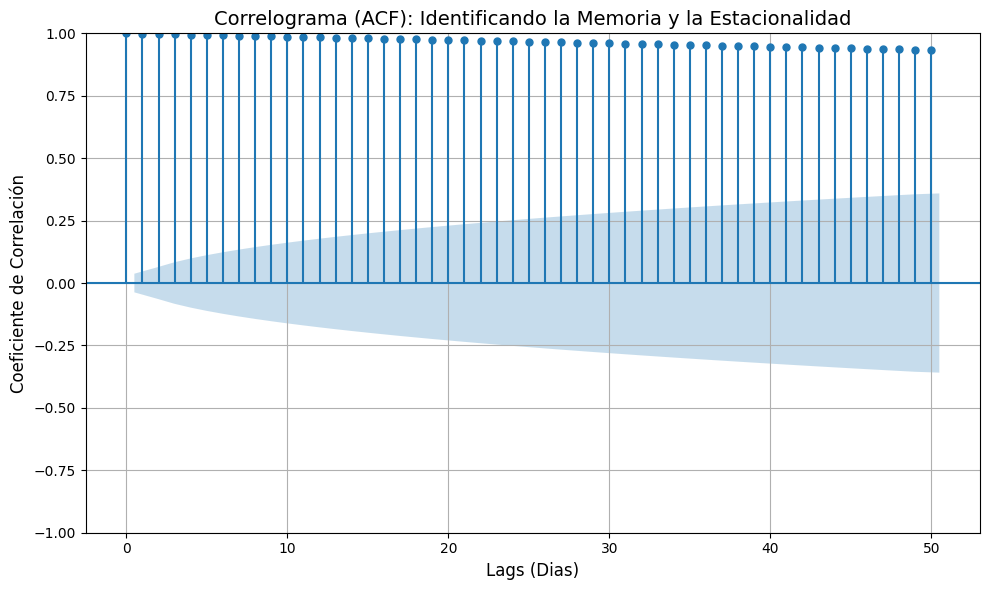

In [ ]:
# 2.13. Prueba de Estacionariedad (Dickey-Fuller) y Autocorrelación:

series_for_test = daily_data

# Prueba de Estacionariedad (Dickey-Fuller)
# Si p-valor > 0.05, la serie NO es estacionaria (tiene tendencia o estacionalidad)
prueba_df = adfuller(series_for_test)
print(f'Prueba de Dickey-Fuller (p-valor): {prueba_df[1]:.4f}')
if prueba_df[1] > 0.05:
    print("Resultado: La serie NO es estacionaria (requiere diferenciación).")
else:
    print("Resultado: La serie es estacionaria.")

# Autocorrelación (ACF / Memoria de la serie)
# El correlograma nos mostrará picos en los retrasos (lags) importantes
fig, ax = plt.subplots(figsize=(10, 6)) # Crear figura y ejes explícitamente
plot_acf(series_for_test, lags=50, ax=ax) # Pasar los ejes a plot_acf, ajustamos lags
ax.set_title('Correlograma (ACF): Identificando la Memoria y la Estacionalidad', fontsize=14)
ax.set_xlabel('Lags (Dias)', fontsize=12)
ax.set_ylabel('Coeficiente de Correlación', fontsize=12)
ax.grid(True)
plt.tight_layout()
plt.show()

**3. Modelo Prophet:**

Elegimos el modelo Prophet por el manejo de estacionalidad y por el comportamiento cíclico marcado en la cartera actuarial.

In [ ]:
# 3.1. Preprocesamiento para el Modelo Prophet:

prophet_data = daily_data.copy()

# Resetear el índice para que 'Fecha' sea una columna regular
prophet_data = prophet_data.reset_index()

# Renombrar las columnas para que coincidan con el formato de Prophet
prophet_data = prophet_data.rename(columns={'Fecha': 'ds', 'Valor_Cuota_ATU': 'y'})

print("Primeras 5 filas del DataFrame para Prophet:")
print(prophet_data.head())

Primeras 5 filas del DataFrame para Prophet:
          ds          y
0 2015-01-02  24.251838
1 2015-01-05  24.234056
2 2015-01-06  24.365163
3 2015-01-07  24.465567
4 2015-01-08  24.516389


In [ ]:
# 3.2. Dividir los datos en conjuntos de entrenamiento y prueba

# Definir la fecha de inicio del conjunto de prueba
start_test_date = '2025-01-02'

# Dividir los datos en conjuntos de entrenamiento y prueba por fecha
train_df = prophet_data[prophet_data['ds'] < start_test_date]
test_df = prophet_data[prophet_data['ds'] >= start_test_date]

print("Fechas de inicio y fin del conjunto de entrenamiento:")
print(f"Inicio: {train_df['ds'].min().strftime('%Y-%m-%d')}, Fin: {train_df['ds'].max().strftime('%Y-%m-%d')}")
print(f"Número de observaciones de entrenamiento: {len(train_df)}")

print("\nFechas de inicio y fin del conjunto de prueba:")
print(f"Inicio: {test_df['ds'].min().strftime('%Y-%m-%d')}, Fin: {test_df['ds'].max().strftime('%Y-%m-%d')}")
print(f"Número de observaciones de prueba: {len(test_df)}")

print("\nPrimeras 5 filas del conjunto de entrenamiento:")
print(train_df.head())

print("\nÚltimas 5 filas del conjunto de prueba:")
print(test_df.tail())

Fechas de inicio y fin del conjunto de entrenamiento:
Inicio: 2015-01-02, Fin: 2024-12-31
Número de observaciones de entrenamiento: 2508

Fechas de inicio y fin del conjunto de prueba:
Inicio: 2025-01-02, Fin: 2025-12-31
Número de observaciones de prueba: 252

Primeras 5 filas del conjunto de entrenamiento:
          ds          y
0 2015-01-02  24.251838
1 2015-01-05  24.234056
2 2015-01-06  24.365163
3 2015-01-07  24.465567
4 2015-01-08  24.516389

Últimas 5 filas del conjunto de prueba:
             ds          y
2755 2025-12-24  70.814146
2756 2025-12-26  70.936245
2757 2025-12-29  70.974392
2758 2025-12-30  70.974025
2759 2025-12-31  70.974637


In [ ]:
# 3.3. Instanciar y Entrenar Modelo Prophet con el conjunto de entrenamiento:

# Instanciar el modelo Prophet
model_train = Prophet(
    #interval_width=0.95,  # Intervalo de confianza alteración de 0.80 a 0.95 no cambia las métricas
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False # Se puede añadir si hay datos intradía
)

# Ajustar el modelo solo al conjunto de entrenamiento
model_train.fit(train_df)

print("Modelo Prophet entrenado exitosamente con el conjunto de entrenamiento (train_df).")

# Imprimir los hiperparámetros:
print("Hiperparámetros del modelo Prophet (model_train):")
print(f"  Estacionalidad anual (yearly_seasonality): {model_train.yearly_seasonality}")
print(f"  Orden Fourier anual: {model_train.seasonalities['yearly']['fourier_order']}")
print(f"  Estacionalidad semanal (weekly_seasonality): {model_train.weekly_seasonality}")
print(f"  Orden Fourier semanal: {model_train.seasonalities['weekly']['fourier_order']}")
print(f"  Estacionalidad diaria (daily_seasonality): {model_train.daily_seasonality}")
print(f"  Intervalo de confianza (interval_width): {model_train.interval_width}")
print(f"  Escala de la tendencia (changepoint_prior_scale): {model_train.changepoint_prior_scale}")
print(f"  Escala de la estacionalidad (seasonality_prior_scale): {model_train.seasonality_prior_scale}")
print(f"  Modo de estacionalidad (seasonality_mode): {model_train.seasonality_mode}")


Modelo Prophet entrenado exitosamente con el conjunto de entrenamiento (train_df).
Hiperparámetros del modelo Prophet (model_train):
  Estacionalidad anual (yearly_seasonality): True
  Orden Fourier anual: 10
  Estacionalidad semanal (weekly_seasonality): True
  Orden Fourier semanal: 3
  Estacionalidad diaria (daily_seasonality): False
  Intervalo de confianza (interval_width): 0.8
  Escala de la tendencia (changepoint_prior_scale): 0.05
  Escala de la estacionalidad (seasonality_prior_scale): 10.0
  Modo de estacionalidad (seasonality_mode): additive


In [ ]:
# 3.4. Realizar predicciones sobre test_df

# Crear un DataFrame futuro basado en test_df
future_test_df = pd.DataFrame({'ds': test_df['ds']})

# Realizar predicciones con el modelo entrenado en train_df
forecast_test_model = model_train.predict(future_test_df)

print("Primeras 5 filas de las predicciones para el conjunto de prueba:")
print(forecast_test_model[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

Primeras 5 filas de las predicciones para el conjunto de prueba:
          ds       yhat  yhat_lower  yhat_upper
0 2025-01-02  63.387378   62.807259   63.956884
1 2025-01-03  63.433908   62.840216   64.043306
2 2025-01-06  63.507708   62.920430   64.104296
3 2025-01-07  63.554536   62.959890   64.128724
4 2025-01-08  63.591328   63.000584   64.170819


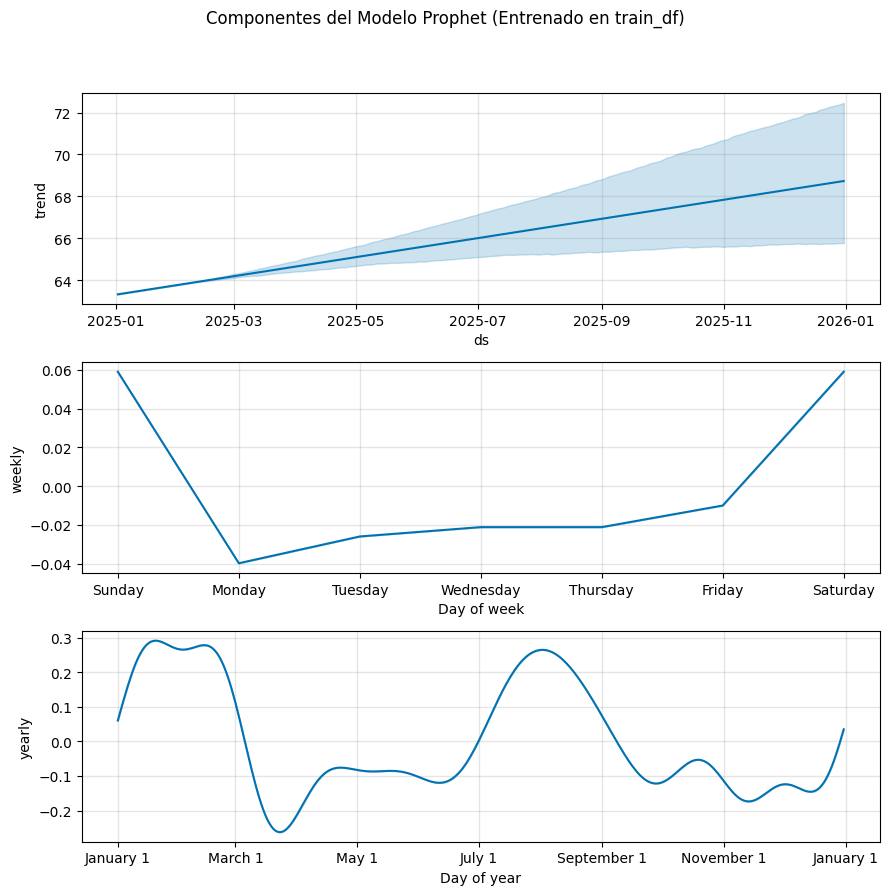

Los gráficos muestran la tendencia, la estacionalidad anual y la estacionalidad semanal identificadas por el modelo.


In [ ]:
# 3.5. Explorar los componentes de estacionalidad y tendencia del modelo

# Generar el gráfico de componentes
fig_components = model_train.plot_components(forecast_test_model)

plt.suptitle('Componentes del Modelo Prophet (Entrenado en train_df)', y=1.02) # Ajustar el título principal
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Ajustar el layout para el título principal
plt.show()

print("Los gráficos muestran la tendencia, la estacionalidad anual y la estacionalidad semanal identificadas por el modelo.")

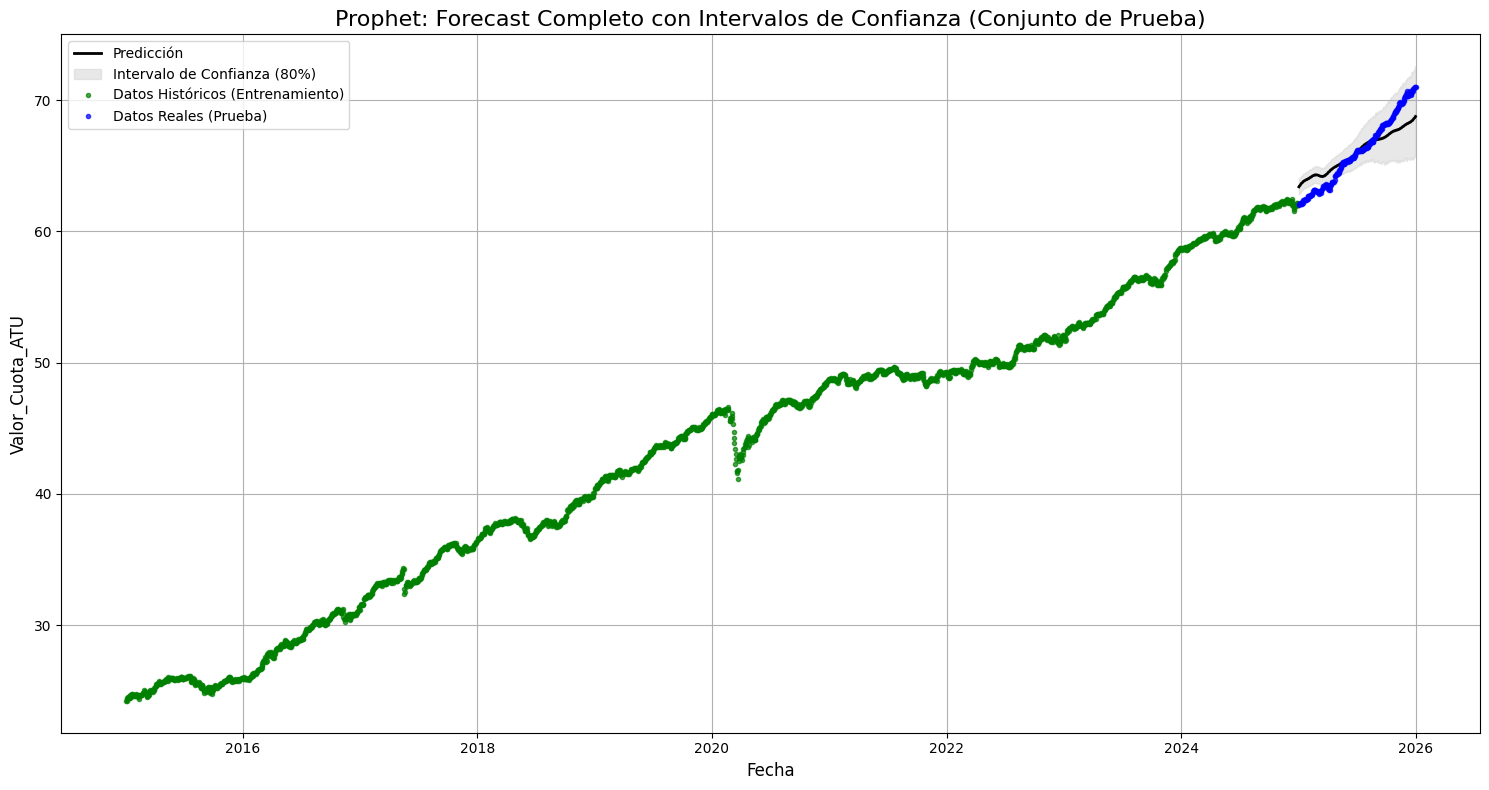

In [ ]:
# 3.6. Visualizar el forecast completo con intervalos de confianza

plt.figure(figsize=(15, 8))

# Plotear la predicción y el intervalo de confianza del modelo
plt.plot(forecast_test_model['ds'], forecast_test_model['yhat'], color='black', label='Predicción', linewidth=2)
plt.fill_between(
    forecast_test_model['ds'],
    forecast_test_model['yhat_lower'],
    forecast_test_model['yhat_upper'],
    color='lightgray', alpha=0.5, label='Intervalo de Confianza (80%)'
)

# Añadir los datos históricos (del conjunto de entrenamiento) para una mejor comparación
plt.plot(train_df['ds'], train_df['y'], 'o', markersize=3, color='green', alpha=0.7, label='Datos Históricos (Entrenamiento)')
plt.plot(test_df['ds'], test_df['y'], 'o', markersize=3, color='blue', alpha=0.7, label='Datos Reales (Prueba)')

plt.title('Prophet: Forecast Completo con Intervalos de Confianza (Conjunto de Prueba)', fontsize=16)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Valor_Cuota_ATU', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

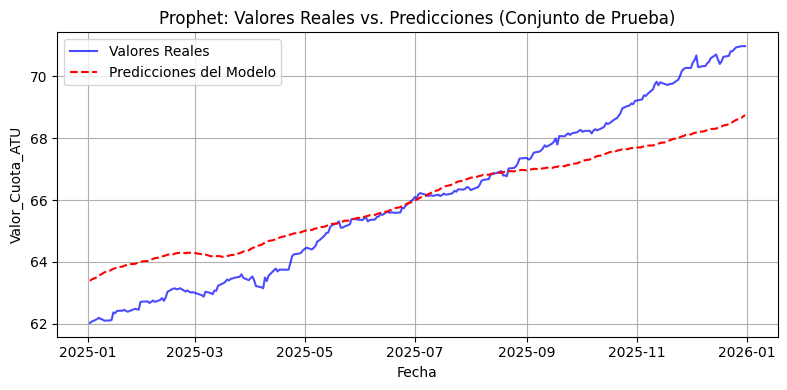

Métricas de Evaluación del Modelo Prophet (entrenado en train_df) en el conjunto de prueba:
  MAE (Mean Absolute Error): 0.9368
  RMSE (Root Mean Squared Error): 1.1627
  MAPE (Mean Absolute Percentage Error): 1.41%


In [ ]:
# 3.7. Gráfico Real vs Predicho y evaluación del modelo

# Asegurarse de que forecast_test_model y test_df estén alineados por fecha
eval_df = test_df.set_index('ds').join(forecast_test_model.set_index('ds')[['yhat']]).reset_index()

plt.figure(figsize=(8, 4))
plt.plot(eval_df['ds'], eval_df['y'], label='Valores Reales', color='blue', alpha=0.7)
plt.plot(eval_df['ds'], eval_df['yhat'], label='Predicciones del Modelo', color='red', linestyle='--')

plt.title('Prophet: Valores Reales vs. Predicciones (Conjunto de Prueba)')
plt.xlabel('Fecha')
plt.ylabel('Valor_Cuota_ATU')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Calcular MAE
mae = mean_absolute_error(eval_df['y'], eval_df['yhat'])

# Calcular RMSE
rmse = np.sqrt(mean_squared_error(eval_df['y'], eval_df['yhat']))

# Calcular MAPE (manejo de división por cero si hay valores de 'y' cercanos a cero)
# Se excluyen los casos donde el valor real es cero para evitar infinitos en el porcentaje.
mape = np.mean(np.abs((eval_df['y'] - eval_df['yhat']) / eval_df['y'].replace(0, np.nan).dropna())) * 100

print(f"Métricas de Evaluación del Modelo Prophet (entrenado en train_df) en el conjunto de prueba:")
print(f"  MAE (Mean Absolute Error): {mae:.4f}")
print(f"  RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"  MAPE (Mean Absolute Percentage Error): {mape:.2f}%")

A pesar del excelente resultado del modelo **Prophet**, es importante recuerdar que el modelo asume que el futuro seguirá tendencias pasadas, lo cual **no siempre ocurre en finanzas** debido a eventos inesperados.

**4. Modelo RNN - LSTM (Long Short-Term Memory):**

In [ ]:
# 4.1. Modelado LSTM

print("Preparando los datos para el modelo LSTM...")

# Añadir semillas para reproducibilidad
seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)   # Semillas para el módulo random de Python
np.random.seed(seed_value) # Semillas para numpy
tf.random.set_seed(seed_value)  # Semillas para tensorflow y keras

# Crea una instancia de MinMaxScaler con un rango de 0 a 1.
scaler = MinMaxScaler(feature_range=(0, 1))

# Escala la serie daily_data utilizando el escalador.
# Remodelar daily_data a un formato 2D antes de escalarla
scaled_data = scaler.fit_transform(daily_data.values.reshape(-1, 1))

# Define una longitud para las secuencias de entrada (e.g., n_input = 30).
n_input = 30

# Obtener los índices para la división, asegurándose de que 'daily_data' es el que se usa

# Asegurarse de que daily_data.index es de tipo datetime
if not isinstance(daily_data.index, pd.DatetimeIndex):
    daily_data.index = pd.to_datetime(daily_data.index)

# Encontrar el índice de la fecha de inicio de prueba en daily_data utilizando la primera fecha real del test_df
test_start_idx = daily_data.index.get_loc(test_df['ds'].min())

# Define la longitud del conjunto de validación (e.g., últimos 90 días del set de entrenamiento original)
validation_length = 90

# Calcula el punto de división para el nuevo conjunto de entrenamiento y validación
val_split_idx = test_start_idx - validation_length

# Data para el generador de entrenamiento
train_data_for_generator_new = scaled_data[:val_split_idx]

# Data para el generador de validación (incluye n_input look-back desde el train_data_for_generator_new)
val_data_for_generator = scaled_data[val_split_idx - n_input : test_start_idx]

# Data para el generador de prueba/validación
# Necesitamos datos desde n_input antes del inicio real de la prueba para crear las primeras secuencias de prueba
test_data_for_generator = scaled_data[test_start_idx - n_input:]

print(f"Tamaño total de datos escalados: {len(scaled_data)}")
print(f"Tamaño de los datos para el generador de entrenamiento: {len(train_data_for_generator_new)}")
print(f"Tamaño de los datos para el generador de validación: {len(val_data_for_generator)}")
print(f"Tamaño de los datos para el generador de prueba: {len(test_data_for_generator)}")

# Utiliza TimeseriesGenerator para crear las secuencias de entrenamiento, validación y prueba.
train_generator = TimeseriesGenerator(train_data_for_generator_new, train_data_for_generator_new, length=n_input, batch_size=1)
val_generator = TimeseriesGenerator(val_data_for_generator, val_data_for_generator, length=n_input, batch_size=1)
test_generator = TimeseriesGenerator(test_data_for_generator, test_data_for_generator, length=n_input, batch_size=1)

print(f"Número de secuencias en train_generator: {len(train_generator)}")
print(f"Número de secuencias en val_generator: {len(val_generator)}")
print(f"Número de secuencias en test_generator: {len(test_generator)}")

print("Datos preparados para el modelo LSTM.")

Preparando los datos para el modelo LSTM...
Tamaño total de datos escalados: 2760
Tamaño de los datos para el generador de entrenamiento: 2418
Tamaño de los datos para el generador de validación: 120
Tamaño de los datos para el generador de prueba: 282
Número de secuencias en train_generator: 2388
Número de secuencias en val_generator: 90
Número de secuencias en test_generator: 252
Datos preparados para el modelo LSTM.


In [ ]:
# 4.2. Definición del modelo y entrenamiento:

print("Definiendo la arquitectura del modelo LSTM...")

# Inicializa un modelo secuencial de Keras
model_lstm = Sequential()

# Agrega una capa LSTM con 50 unidades
# La forma de entrada es (n_input, n_features). n_features es 1 porque es una serie univariada.
model_lstm.add(LSTM(50, activation='relu', input_shape=(n_input, 1), return_sequences=False))

# Agrega una capa Dropout con una tasa del 20% para regularización.
model_lstm.add(Dropout(0.2))

# Agrega una capa Dense (capa de salida) con 1 unidad.
model_lstm.add(Dense(1))

# Compila el modelo
# Usamos 'adam' como optimizador y 'mse' (Mean Squared Error) como función de pérdida para regresión.
model_lstm.compile(optimizer='adam', loss='mse')

# Muestra un resumen de la arquitectura del modelo
model_lstm.summary()

print("Arquitectura del modelo LSTM definida exitosamente.")

# Entrenamiento:

# Configura EarlyStopping para evitar el sobreajuste.
# El entrenamiento se detendrá si la pérdida de validación no mejora durante 5 épocas.
early_stop = EarlyStopping(monitor='val_loss', patience=5, verbose=1)

# Entrena el modelo utilizando los generadores de datos.
# Se usará un número razonable de épocas (por ejemplo, 50-100) y el callback de EarlyStopping.
history = model_lstm.fit(
    train_generator,
    epochs=100,
    validation_data=val_generator, # Ahora usa el generador de validación
    callbacks=[early_stop],
    verbose=1
)

print("Modelo LSTM entrenado exitosamente.")

Definiendo la arquitectura del modelo LSTM...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Arquitectura del modelo LSTM definida exitosamente.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 36s 12ms/step - loss: 0.0142 - val_loss: 1.0177e-05
Epoch 2/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 30s 13ms/step - loss: 0.0021 - val_loss: 0.0012
Epoch 3/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 30s 12ms/step - loss: 0.0016 - val_loss: 8.8865e-06
Epoch 4/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 0.0014 - val_loss: 7.4776e-04
Epoch 5/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 31s 13ms/step - loss: 0.0013 - val_loss: 1.7004e-05
Epoch 6/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 39s 12ms/step - loss: 0.0013 - val_loss: 1.7552e-04
Epoch 7/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 29s 12ms/step - loss: 0.0013 - val_loss: 0.0017
Epoch 8/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 29s 12ms/step - loss: 0.0014 - val_loss: 3.8429e-04
Epoch 8: early stopping
Modelo LSTM entrenado exitosamente.



--- ANÁLISIS DE LA CURVA ---
Observa el punto donde la 'Pérdida de Validación' empieza a subir mientras la 'Pérdida de Entrenamiento' sigue bajando. ¡Ese es el Overfitting!
La mejor época para detener el entrenamiento es cuando la Precisión de Validación es máxima.


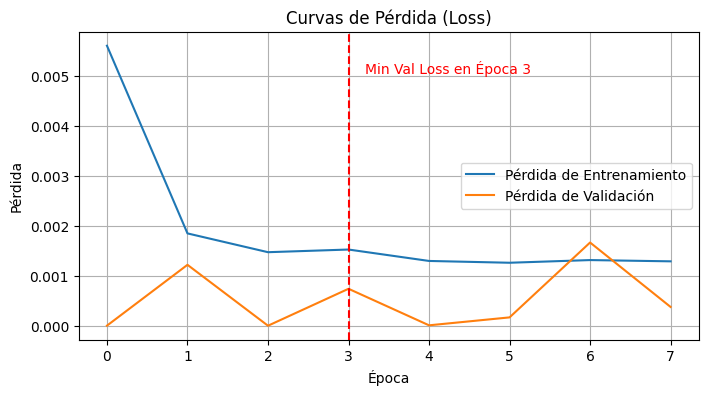

In [ ]:
# 4.3. Gráfico de Pérdida (Loss)

plt.figure (figsize=(8,4))
plt.xticks (np.arange(0,21,1))
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de Validación')
plt.title('Curvas de Pérdida (Loss)')
plt.legend()
plt.grid(True)
plt.axvline(x=np.argmin(history.history['val_loss']) + 1, color='red', linestyle='--', label='Mejor Época (Validación)')
plt.text(np.argmin(history.history['val_loss']) + 1.2, max(history.history['loss'])*0.9,
         f'Min Val Loss en Época {np.argmin(history.history["val_loss"])+ 1 }',
         color='red', fontsize=10)

print("\n--- ANÁLISIS DE LA CURVA ---")
print("Observa el punto donde la 'Pérdida de Validación' empieza a subir mientras la 'Pérdida de Entrenamiento' sigue bajando. ¡Ese es el Overfitting!")
print("La mejor época para detener el entrenamiento es cuando la Precisión de Validación es máxima.")



252/252 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


,Fecha,Real,Predicho
0,2025-01-02,62.028935,61.135109
1,2025-01-03,62.069372,61.134312
2,2025-01-06,62.152618,61.142826
3,2025-01-07,62.193976,61.171040
4,2025-01-08,62.156295,61.203663


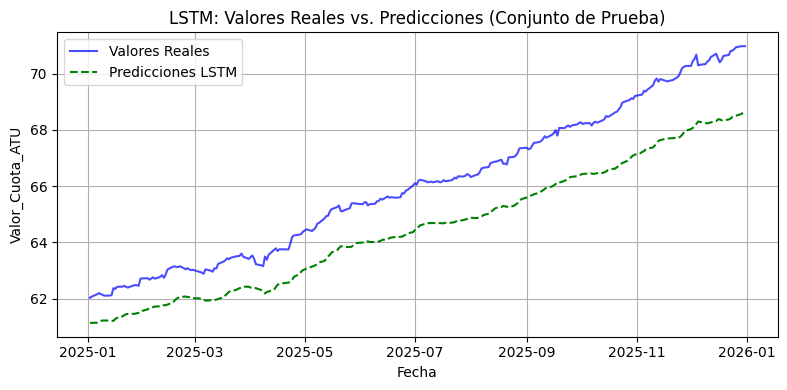


Métricas de Evaluación del Modelo LSTM en el conjunto de prueba:
  MAE (Mean Absolute Error): 1.5634
  RMSE (Root Mean Squared Error): 1.6185
  MAPE (Mean Absolute Percentage Error): 2.34%


In [ ]:
# 4.4. Hacer las predicciones en el conjunto de prueba, calcular las métricas y visualizar el real vs predicho

# Hacer predicciones en el conjunto de prueba
predictions_scaled = model_lstm.predict(test_generator)

# Invertir la escala de las predicciones a la escala original
predictions = scaler.inverse_transform(predictions_scaled)

# Obtener los valores reales del conjunto de prueba (también invertir la escala)
# test_data_for_generator contiene la secuencia de n_input para el primer punto de prueba,
# por lo que los valores reales comienzan desde n_input en adelante.
real_values_scaled = test_data_for_generator[n_input:]
real_values = scaler.inverse_transform(real_values_scaled)

# Crear un DataFrame para comparar los valores reales y predichos
# Las fechas para el conjunto de prueba están en test_df['ds']
comparison_df = pd.DataFrame({
    'Fecha': test_df['ds'].values,
    'Real': real_values.flatten(),
    'Predicho': predictions.flatten()
})

display(comparison_df.head())

# Calcular métricas de evaluación
mae_lstm = mean_absolute_error(real_values, predictions)
rmse_lstm = np.sqrt(mean_squared_error(real_values, predictions))

# Calcular MAPE (manejo de división por cero si hay valores de 'y' cercanos a cero)
mape_lstm = np.mean(np.abs((real_values - predictions) / real_values)) * 100

# Visualizar el real vs predicho
plt.figure(figsize=(8, 4))
plt.plot(comparison_df['Fecha'], comparison_df['Real'], label='Valores Reales', color='blue', alpha=0.7)
plt.plot(comparison_df['Fecha'], comparison_df['Predicho'], label='Predicciones LSTM', color='green', linestyle='--')
plt.title('LSTM: Valores Reales vs. Predicciones (Conjunto de Prueba)')
plt.xlabel('Fecha')
plt.ylabel('Valor_Cuota_ATU')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nMétricas de Evaluación del Modelo LSTM en el conjunto de prueba:")
print(f"  MAE (Mean Absolute Error): {mae_lstm:.4f}")
print(f"  RMSE (Root Mean Squared Error): {rmse_lstm:.4f}")
print(f"  MAPE (Mean Absolute Percentage Error): {mape_lstm:.2f}%")


**5. Modelo GARCH (Generalized Autoregressive Conditional Heteroskedasticity)**

In [ ]:
# 5.1. Preparar los datos: Calcular los retornos diarios

# Asegurarse de que daily_data sea un DataFrame o Series con índice de fecha
# y que esté ordenado cronológicamente
daily_data_garch = daily_data.copy().sort_index()

# Calcular los retornos logarítmicos (diferencia del logaritmo del valor)
# Multiplicar por 1000 para llevar la escala a un rango recomendado (1-1000).
returns = 1000 * daily_data_garch.pct_change().dropna()

# Alternativamente, para retornos logarítmicos:
# returns = 1000 * np.log(daily_data_garch / daily_data_garch.shift(1)).dropna()

print("Primeras 5 filas de los retornos diarios (escalados por 1000):")
display(returns.head())
print(f"Número de observaciones de retornos: {len(returns)}")

Primeras 5 filas de los retornos diarios (escalados por 1000):


,Valor_Cuota_ATU
Fecha,
2015-01-05,-0.733223
2015-01-06,5.410039
2015-01-07,4.120784
2015-01-08,2.077277
2015-01-09,2.090467


Número de observaciones de retornos: 2759


In [ ]:
# 5.2. Ajustar el modelo GARCH(1,1)

# Definir el modelo GARCH(1,1)
# mean='Constant' asume una media constante para los retornos
# vol='GARCH' especifica el modelo de volatilidad GARCH
# p=1 y q=1 para GARCH(1,1)
model_garch = arch.arch_model(returns, mean='Constant', vol='GARCH', p=1, q=1)

# Ajustar el modelo a los datos de retornos
garch_results = model_garch.fit(update_freq=5, disp='off')

print("Modelo GARCH(1,1) ajustado con éxito.")

# Mostrar el resumen de los resultados del modelo
print(garch_results.summary())

Modelo GARCH(1,1) ajustado con éxito.
                     Constant Mean - GARCH Model Results                      
Dep. Variable:        Valor_Cuota_ATU   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -6381.96
Distribution:                  Normal   AIC:                           12771.9
Method:            Maximum Likelihood   BIC:                           12795.6
                                        No. Observations:                 2759
Date:                Wed, Mar 11 2026   Df Residuals:                     2758
Time:                        15:36:58   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.4039  4.838e-02

Pronóstico de la varianza condicional para los próximos 5 días:


,h.1,h.2,h.3,h.4,h.5
Fecha,,,,,
2025-12-31,2.265446,2.484308,2.703169,2.92203,3.140892


Pronóstico de la volatilidad (desviación estándar) para los próximos 5 días:


,h.1,h.2,h.3,h.4,h.5
Fecha,,,,,
2025-12-31,1.50514,1.576169,1.644132,1.709395,1.772256


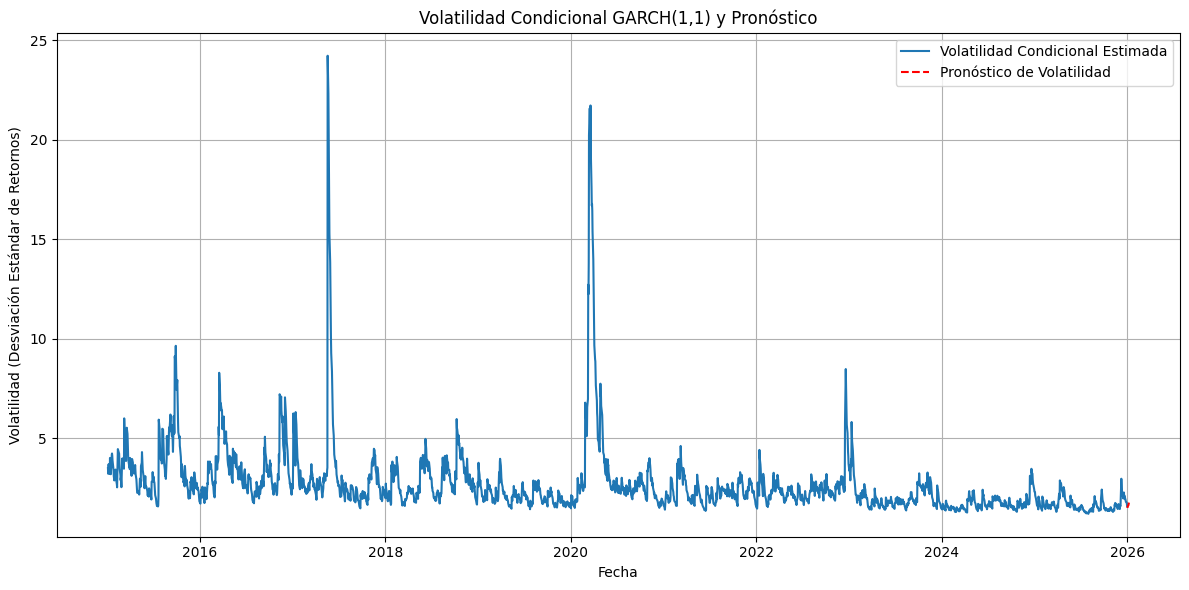

In [ ]:
# 5.3. Pronosticar la volatilidad futura

# Pronosticar la volatilidad para los próximos días (por ejemplo, 5 días)
# El método 'forecast' devuelve la media condicional (h.mean) y la varianza condicional (h.variance)
# Horizon especifica cuántos pasos hacia adelante se desea pronosticar
forecast_horizon = 5
garch_forecast = garch_results.forecast(horizon=forecast_horizon, reindex=False)

print(f"Pronóstico de la varianza condicional para los próximos {forecast_horizon} días:")
display(garch_forecast.variance.tail())

# Para obtener la desviación estándar (volatilidad), se toma la raíz cuadrada de la varianza
forecast_volatility = np.sqrt(garch_forecast.variance)

print(f"Pronóstico de la volatilidad (desviación estándar) para los próximos {forecast_horizon} días:")
display(forecast_volatility.tail())

# Visualizar la volatilidad condicional
plt.figure(figsize=(12, 6))
plt.plot(garch_results.conditional_volatility, label='Volatilidad Condicional Estimada')

# Generar fechas futuras para el pronóstico
last_date_in_data = garch_results.conditional_volatility.index.max()
# Crear un rango de fechas para el pronóstico (excluyendo el primer día para evitar duplicados en el gráfico)
forecast_dates = pd.date_range(start=last_date_in_data + pd.Timedelta(days=1), periods=forecast_horizon, freq='B') # 'B' para días hábiles

# Alinear las fechas de pronóstico con los valores de pronóstico
# forecast_volatility.iloc[-1, :] selecciona la última fila (que corresponde a la última fecha del forecast) y todas las columnas h.1, h.2, etc.
plt.plot(forecast_dates, forecast_volatility.iloc[-1, :], color='red', linestyle='--', label='Pronóstico de Volatilidad')

plt.title('Volatilidad Condicional GARCH(1,1) y Pronóstico')
plt.xlabel('Fecha')
plt.ylabel('Volatilidad (Desviación Estándar de Retornos)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**6. Conclusiones:**

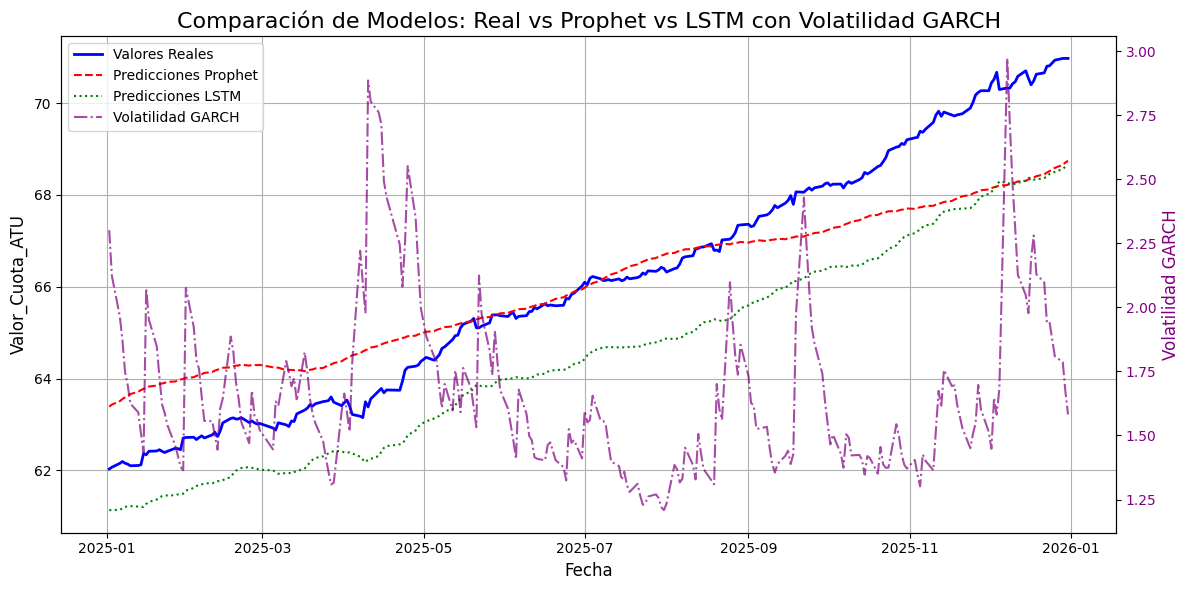

In [ ]:
# 6.1. Gráfico con la comparación de todos los modelos vs los datos actuales:

fig, ax1 = plt.subplots(figsize=(12, 6))

# Eje Y principal para los valores de la cuota
ax1.plot(test_df['ds'], test_df['y'], label='Valores Reales', color='blue', linewidth=2)
ax1.plot(forecast_test_model['ds'], forecast_test_model['yhat'], label='Predicciones Prophet', color='red', linestyle='--')
ax1.plot(comparison_df['Fecha'], comparison_df['Predicho'], label='Predicciones LSTM', color='green', linestyle=':')

ax1.set_xlabel('Fecha', fontsize=12)
ax1.set_ylabel('Valor_Cuota_ATU', fontsize=12, color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_title('Comparación de Modelos: Real vs Prophet vs LSTM con Volatilidad GARCH', fontsize=16)
ax1.grid(True)

# Crear un segundo eje Y para la volatilidad GARCH
ax2 = ax1.twinx()

# Filtrar la volatilidad condicional para el rango de fechas del test_df
volatility_for_plot = garch_results.conditional_volatility.loc[test_df['ds'].min():test_df['ds'].max()]

# Asegurarse de que el índice del forecast de volatilidad sea de tipo datetime y tenga el mismo nombre de columna 'Fecha' para que se pueda unir
# Si forecast_volatility contiene solo una fila, como en este caso, se puede trazar como una línea horizontal
# No es una serie de tiempo continua, sino forecasts a diferentes horizontes desde el último punto.
# Por lo tanto, usaremos la volatilidad condicional 'in-sample' para el período de prueba.

ax2.plot(volatility_for_plot.index, volatility_for_plot.values, label='Volatilidad GARCH', color='purple', linestyle='-.', alpha=0.7)
ax2.set_ylabel('Volatilidad GARCH', fontsize=12, color='purple')
ax2.tick_params(axis='y', labelcolor='purple')

# Combinar leyendas de ambos ejes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()

**Conclusiones**: Según el análisis y las métricas obtenidas, el mejor modelo para la predicción del valor de la cuota de la cartera Actuarial del fondo de inversión es el Prophet con el menor error (1.41%).

**Limitaciones**: Para el modelo Prophet la asunción de tendencias pasadas, para el modelo LSTM el tema de la caja negra, así como la sensibilidad a los hiperparámetros y para el modelo Garch la asunción de simetría en shocks entre otros.

**Propuestas de mejoras:** Inclusión de variables exógenas como por ejemplo la inflación y la tasa de interés o intentar modelos híbridos como por ejemplo LSTM-Garch, VaR-Garch, etc.